In [1]:
from pathlib import Path

import cv2
import imutils
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / 'data' / 'images'
WIDE_ROOT = DATA_ROOT / 'orga_widecrop'
CROP_ROOT = DATA_ROOT / 'orga_cropping'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Wide root : {WIDE_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Wide root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_widecrop
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_cropping


## Autocrop

In [63]:
manifest = pd.read_csv(OUTPUT_DIR / 'manifest.csv')

usable_pairs = manifest[manifest['statut'] == 'paire_exploitable'].copy()
sample_indices = np.random.choice(len(usable_pairs), size=min(10, len(usable_pairs)), replace=False)

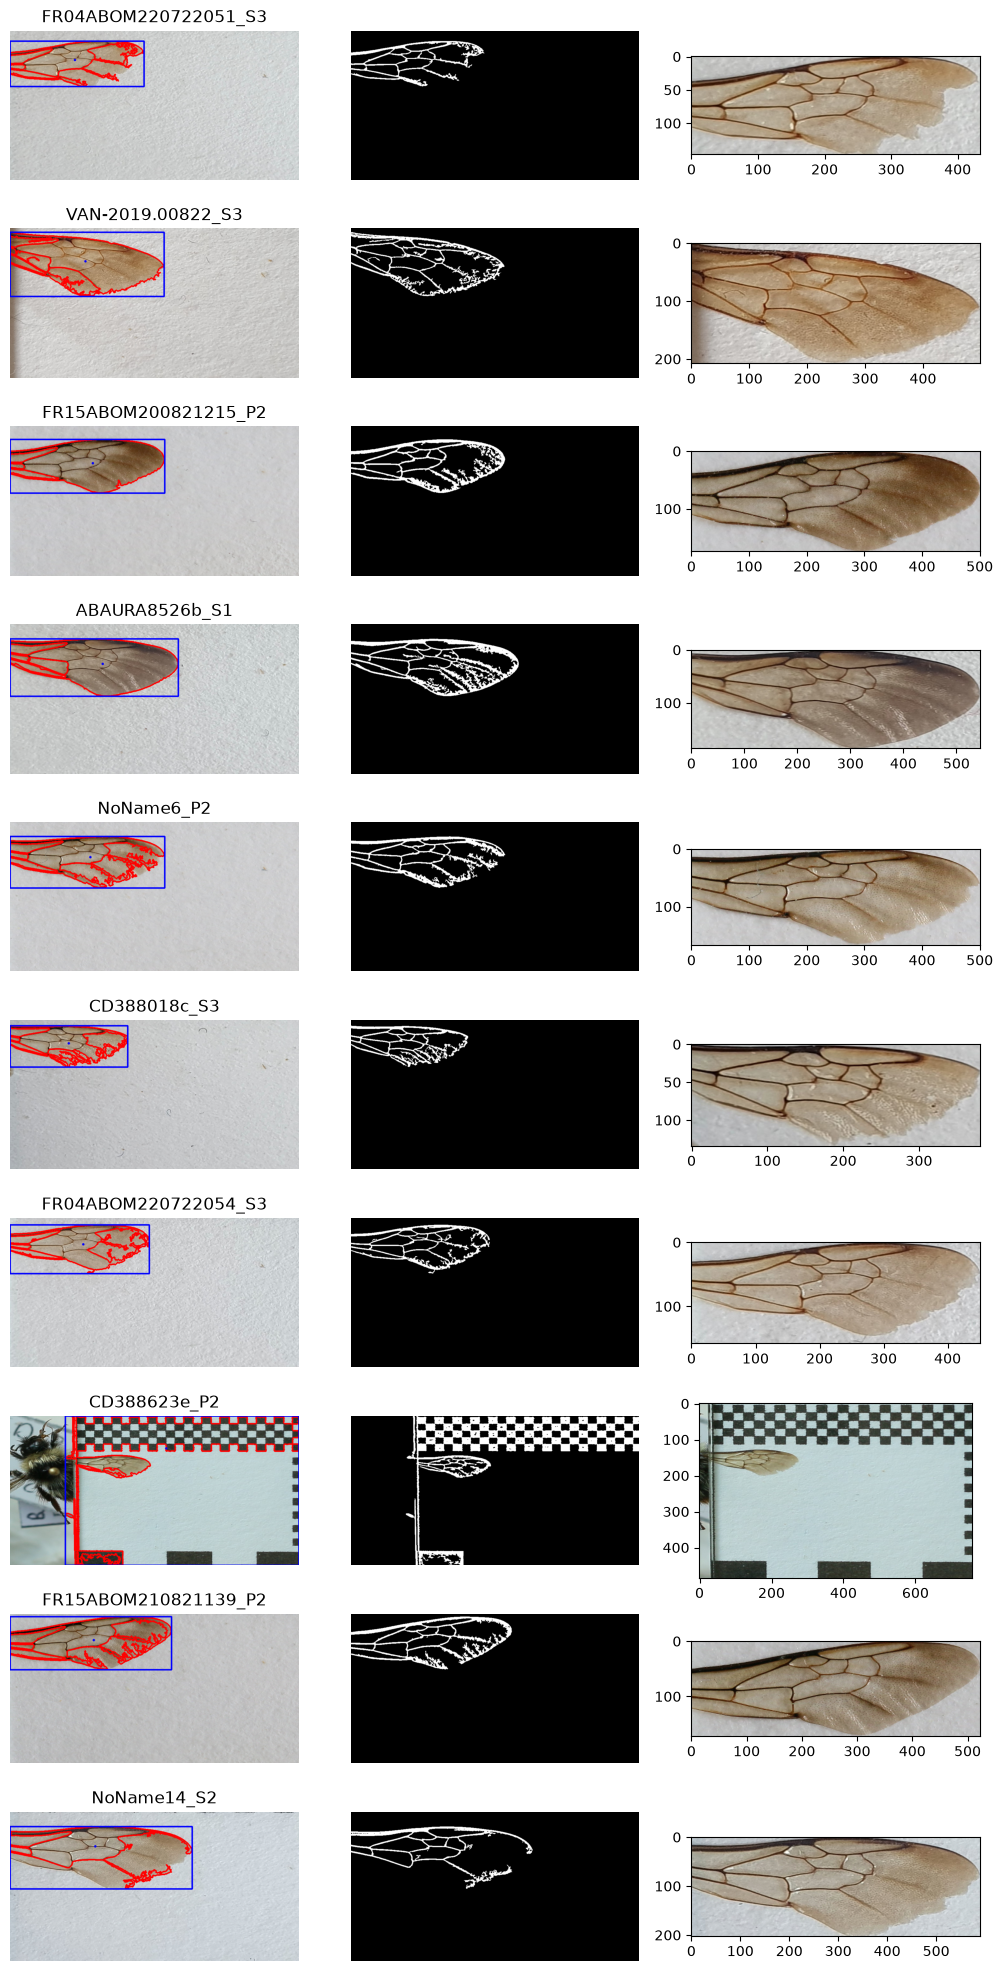

In [69]:
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, 2*len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    crop_path = PROJECT_ROOT / usable_pairs.iloc[idx]['chemin_crop_large']
    image = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
    
    image = cv2.resize(image, (960, 540))
    image = image[56:, 24:]
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 2)
    
    # -------- CONTOURS --------
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    x1, y1, w1, h1 = cv2.boundingRect(c)

    # -- CONNECTED COMPONENTS --
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh,
        connectivity=8, ltype=cv2.CV_32S)

    largest_label = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
    component_mask = (labels == largest_label).astype(np.uint8) * 255

    x2, y2, w2, h2 = stats[largest_label, :-1]
    (cX, cY) = centroids[largest_label]

    # ---------- PLOT ----------
    output = image.copy()
    # countours bbox
    cv2.drawContours(output, [c], -1, (0, 0, 255), 3)
    cv2.rectangle(output, (x1, y1), (x1 + w1, y1 + h1), (0, 255, 0), 3)
    # connected bbox
    cv2.rectangle(output, (x2, y2), (x2 + w2, y2 + h2), (255, 0, 0), 3)
    cv2.circle(output, (int(cX), int(cY)), 4, (255, 0, 0), -1)

    axes[row, 0].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    axes[row, 1].imshow(cv2.cvtColor(component_mask, cv2.COLOR_BGR2RGB))
    axes[row, 2].imshow(cv2.cvtColor(image[y2:y2+h2,x2:x2+w2], cv2.COLOR_BGR2RGB))

    axes[row, 0].set_title(f'{crop_path.stem}')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')


plt.tight_layout()
plt.show()